# <span style="color:green"> Numerical Simulation Laboratory (NSL) </span>
## <span style="color:blue">  Numerical exercises 2</span>


### Exercise 02.2
- <span style="color:red">3D Random Walks (RW) on a cubic lattice and in the continuum:</span> Repeat many times (e.g. say $10^4$) the simulation of a random walk in 3D always starting at the origin

1. on a cubic lattice with lattice constant $a=1$; at each discrete time the walker makes a forward or backward step of length equal to $a$ in one of the 3 principal directions of the lattice: $x$, $y$ or $z$
2. in the continuum; at each discrete time the walker makes a step of length equal to $a(=1)$ along a **random direction** obtained by sampling **uniformly** the solid angle: $\theta \in [0,\pi]$ and $\phi \in [0,2\pi]$

<span style="color:red">Show a picture of $\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$ for both RWs</span>, with their statistical uncertainties, as function of the step $i\in [0,10^2]$.

Suggestion: divide your $M$ throws into a reasonable number of blocks, compute $\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$ as function of the step $i\in [0,10^2]$ in each block and use these values (for fixed $i$) to obtain the average value and its statistical uncertainty.

Note that you could try to fit both results with a function like $f(N)=k\sqrt{N}$. Do your results indicate a diffusive behavior?

## **Submission** 

### **Exercise 02.1**
- Compute the following 1D integral via Monte Carlo:
$$
I = \int_0^1 \frac{\pi}{2}\cos(\pi x/2)\,dx = 1
$$

1. sampling a uniform distribution in $[0,1]$;
2. using importance sampling (i.e. sampling a non-uniform probability in $[0,1]$).

The calculations were performed with $M = 10^5$ points and $N = 100$ blocks. The results are saved in `EX2.1/DATA` and the plots are stored in `EX2.1/IMAGES`.

#### **Importance sampling**
By multiplying and dividing by a suitable probability density $d(x)$, a generic integral of a function $g(x)$ can be rewritten as

$$
I = \int \left[\frac{g(\mathbf{x})\,p(\mathbf{x})}{d(\mathbf{x})}\right] d(\mathbf{x})\,d\mathbf{x},
$$

where $d(\mathbf{x}) \geq 0$ for all $\mathbf{x}$, it is normalized, and

$$
\frac{g(\mathbf{x})p(\mathbf{x})}{d(\mathbf{x})} < \infty
$$

almost everywhere.

The variance of the estimator is then

$$
\mathbb{E}\left[\left(\frac{g(\mathbf{x})p(\mathbf{x})}{d(\mathbf{x})}\right)^2\right]
-
\mathbb{E}\left[\frac{g(\mathbf{x})p(\mathbf{x})}{d(\mathbf{x})}\right]^2
=
\int \left[\frac{g(\mathbf{x})p(\mathbf{x})}{d(\mathbf{x})}\right]^2 d(\mathbf{x})\,d\mathbf{x}
-
I^2.
$$

The variance is minimized by choosing a sampling distribution close to the integrand. This leads to the optimal condition

$$
d(\mathbf{x}) = \lambda |g(\mathbf{x})p(\mathbf{x})|.
$$

Therefore, sampling from a distribution similar to the integrand reduces the variance.

Given the constraints on $d(x)$, I approximated the function by a first-order Taylor expansion around $x=1$, since expanding around $x=0$ would yield a nearly uniform distribution. After normalizing, I obtained

$$
d(x) = 2(1-x).
$$
$d(x)$ is always positive for $x \in [0;1)$.
By inverting the cumulative distribution, I was able to generate random numbers distributed according to $d(x)$ which I implemented as `double Random :: es2punto1importance()` in `EX2.1/SOURCE/random.cpp`

#### **Code structure**
```cpp
//...
int main(int argc, char *argv[])
{

    Random rnd{};
    inizializza_generatore_random(rnd);
    const int M = 100000;
    const int N = 100;

    int L = (M / N);

    // vectors that contain respectively the values of the integral calculated with and without importance sampling
    vector<double> f_wo_importance;
    vector<double> integral_importance;

    double random = 0;
    for (int i = 0; i < M; i++)
    {
        f_wo_importance.push_back(coseno_esercizio2punto1(rnd.Rannyu()));
        random = rnd.es2punto1importance();
        integral_importance.push_back(coseno_esercizio2punto1(random) / function_importance(random));
    }
    rnd.SaveSeed();
    datablocking(M, L, N, f_wo_importance, "../DATA/Data2.1.1.dat");
    datablocking(M, L, N, integral_importance, "../DATA/Data2.1.2.dat");

    return 0;
}
//...

double coseno_esercizio2punto1(double x)
{
    // function to find the value of the integrand
    double f = (M_PI / 2.0) * cos((M_PI * x / 2.0));
    return f;
}

double function_importance(double x)
{
    // value of d(x)
    return 2.0 * (1.0 - x);
}

double Random :: es2punto1importance()
{
    // This function samples random numbers from d(x)
    double y = Rannyu();
    double x = 1.0 - sqrt(1.0 - y);
    return x;
}
```

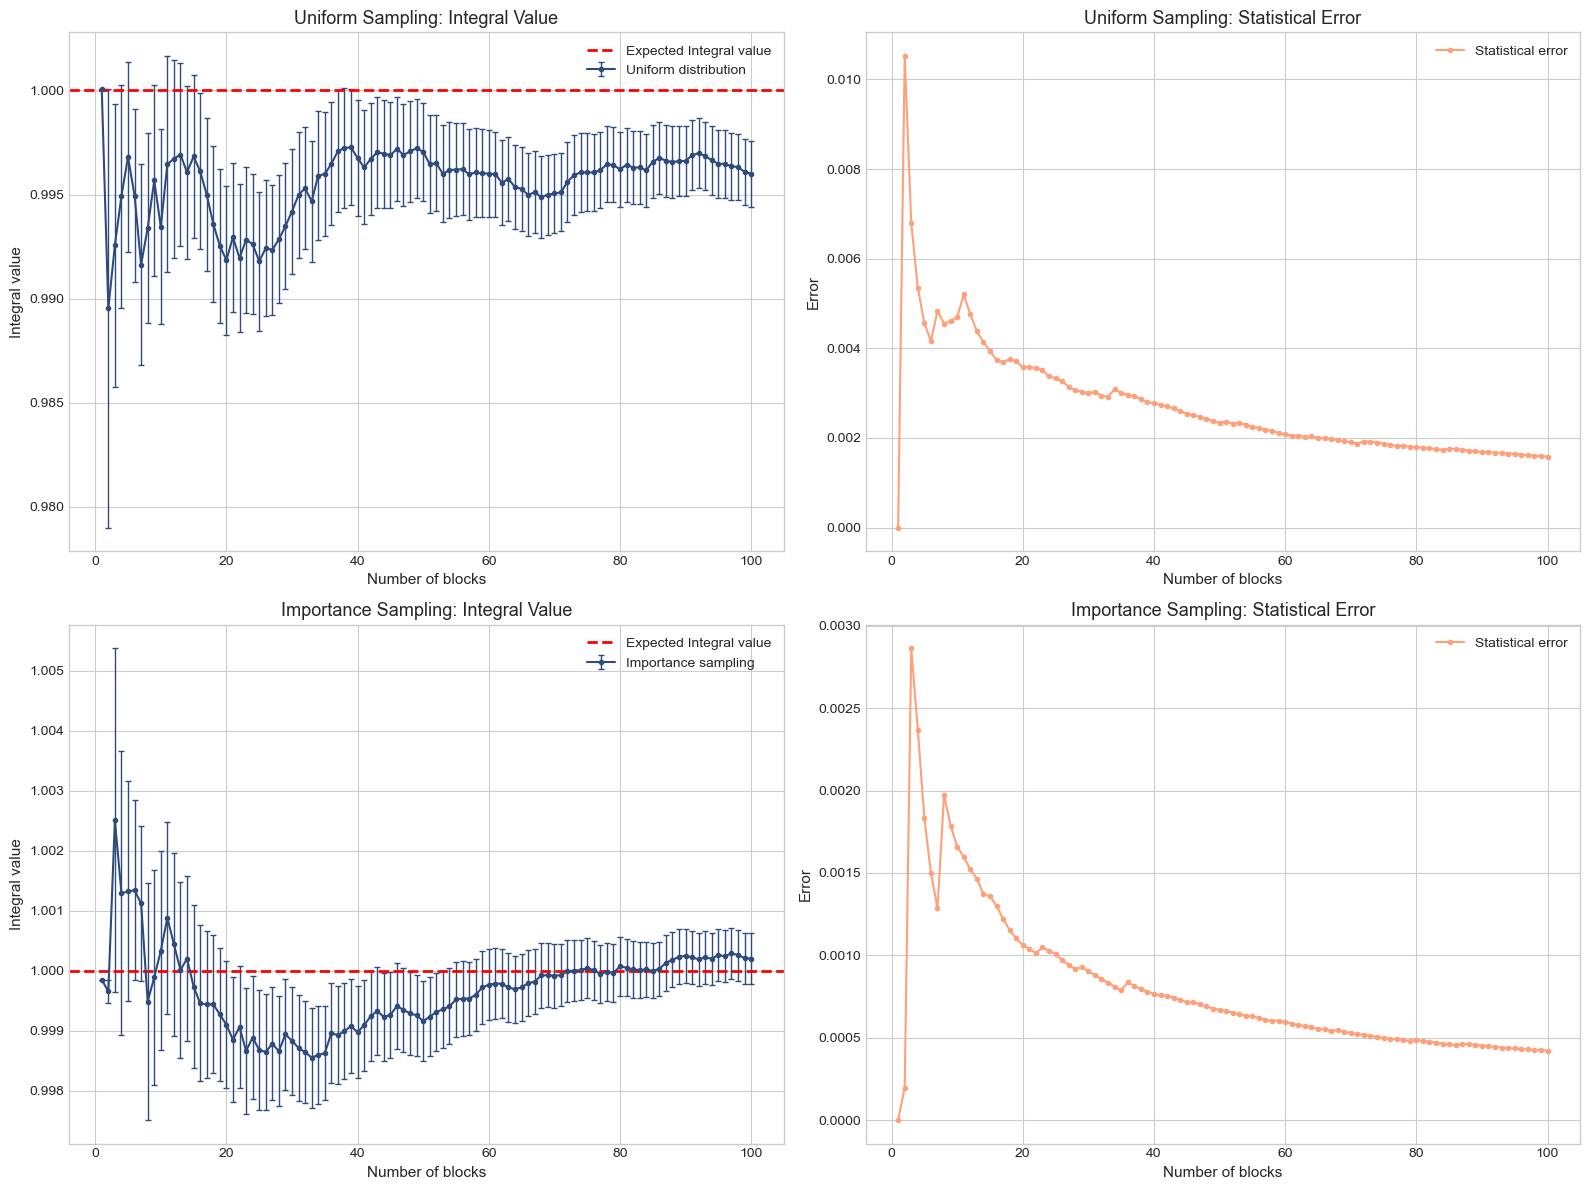

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Caricamento dati
x1, f1, error1_data = np.loadtxt(
    "EX2.1/DATA/Data2.1.1.dat",
    usecols=(0, 1, 2),
    delimiter='\t',
    unpack=True
)

x2, f2, error2_data = np.loadtxt(
    "EX2.1/DATA/Data2.1.2.dat",
    usecols=(0, 1, 2),
    delimiter='\t',
    unpack=True
)

# Impostazione stile e griglia
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# --- RIGA 1: UNIFORM DISTRIBUTION ---

# Valore
axs[0, 0].errorbar(
    x1, f1, yerr=error1_data,
    fmt='o-', markersize=3,
    capsize=2, elinewidth=1,
    label='Uniform distribution',
    color='#2F4B7C'
)
axs[0, 0].axhline(
    y=1.0, color='red', linestyle='--', linewidth=2,
    label='Expected Integral value'
)
axs[0, 0].set_xlabel('Number of blocks', fontsize=11)
axs[0, 0].set_ylabel('Integral value', fontsize=11)
axs[0, 0].set_title('Uniform Sampling: Integral Value', fontsize=13)
axs[0, 0].legend(fontsize=10)

# Errore
axs[0, 1].plot(
    x1, error1_data,
    marker='o', markersize=3, linestyle='-',
    color='#FFA07A', label='Statistical error'
)
axs[0, 1].set_xlabel('Number of blocks', fontsize=11)
axs[0, 1].set_ylabel('Error', fontsize=11)
axs[0, 1].set_title('Uniform Sampling: Statistical Error', fontsize=13)
axs[0, 1].legend(fontsize=10)

# --- RIGA 2: IMPORTANCE SAMPLING ---

# Valore
axs[1, 0].errorbar(
    x2, f2, yerr=error2_data,
    fmt='o-', markersize=3,
    capsize=2, elinewidth=1,
    label='Importance sampling',
    color='#2F4B7C'
)
axs[1, 0].axhline(
    y=1.0, color='red', linestyle='--', linewidth=2,
    label='Expected Integral value'
)
axs[1, 0].set_xlabel('Number of blocks', fontsize=11)
axs[1, 0].set_ylabel('Integral value', fontsize=11)
axs[1, 0].set_title('Importance Sampling: Integral Value', fontsize=13)
axs[1, 0].legend(fontsize=10)

# Errore
axs[1, 1].plot(
    x2, error2_data,
    marker='o', markersize=3, linestyle='-',
    color='#FFA07A', label='Statistical error'
)
axs[1, 1].set_xlabel('Number of blocks', fontsize=11)
axs[1, 1].set_ylabel('Error', fontsize=11)
axs[1, 1].set_title('Importance Sampling: Statistical Error', fontsize=13)
axs[1, 1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('IMAGES/Integral_Comparison.png', dpi=300)
plt.show()

Comparing the two plots one can see how the error found with the importance sampling is at least a tenth of the error without importance sampling (which is exaclty what importance sampling is for!) and in both plots the error scales with $1/\sqrt{N}$ thanks to the data blocking.

### **Exercise 02.2 - Random Walk**
- <span style="color:red">3D Random Walks (RW) on a cubic lattice and in the continuum:</span> Repeat many times (e.g. say $10^4$) the simulation of a random walk in 3D, always starting at the origin.

1. on a cubic lattice with lattice constant $a=1$; at each discrete time the walker makes a forward or backward step of length equal to $a$ in one of the 3 principal directions of the lattice: $x$, $y$ or $z$;
2. in the continuum; at each discrete time the walker makes a step of length equal to $a(=1)$ along a random direction obtained by sampling uniformly the solid angle:
   $$
   \theta \in [0,\pi], \qquad \phi \in [0,2\pi].
   $$

<span style="color:red">Show a picture of $\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$ for both RWs</span>, with their statistical uncertainties, as a function of the step $i \in [0,10^2]$.

To draw the plots, for each number of steps $i \in [0,100]$, I computed $M$ values of $|\vec{r}_N|^2$ (with $M=10000$), and then I stored the cumulative average over $N=100$ blocks. Only after that I evaluated its square root.

#### **Theoretical framework**

The process of a random walk on a lattice can be modeled as a Markov process, i.e. a process for which the conditional probability of an event at $(x_n, t_n)$ depends only on the previous state $(x_{n-1}, t_{n-1})$. Let us consider the 1D case.

Knowing that it is a Markov process, one can write the probability of finding the particle at $x=na$ after $s+1$ time steps as

$$
p_1(na,(s+1)\tau) = \sum_{m=-\infty}^{\infty}
p_{1|1}(na,(s+1)\tau|ma,s\tau)\,p_1(ma,s\tau).
$$

Here $p_{1|1}$ represents the conditional probability for the particle to move from $ma$ to $(m+1)a$ or $(m-1)a$ in a single timestep (the step is fixed of meausure $a$). In the random walk hypothesis, the particle moves to $(m+1)a$ or $(m-1)a$ with equal probability. Therefore,

$$
p_{1|1} = \frac{1}{2}\delta_{n,m+1} + \frac{1}{2}\delta_{n,m-1}.
$$

Subtracting $p_1(na,s\tau)$ from both sides, dividing by $\tau$, and taking the limit $a,\tau \to 0$, one obtains the diffusion equation

$$
\frac{\partial p_1(x,t)}{\partial t}
=
D\,\frac{\partial^2 p_1(x,t)}{\partial x^2},
$$

where

$$
D = \frac{a^2}{2\tau}.
$$

In the case of a random walk starting from the origin, the initial condition (which is the case of this exercise) is

$$
p(x,0) = \delta(x).
$$

Solving the equation in reciprocal space gives the Gaussian solution

$$
p_1(x,t) \propto e^{-x^2/(4Dt)}.
$$

Thus, the variance of the variable $S_N = \sum_i x_i$ is

$$
\sigma^2_{S_N} = N a^2.
$$

As shown by the plots, the typical displacement of the particle from the origin follows a $\sqrt{N}$ law.

#### **Code structure**
To perform this exercise I created a class called `RandomWalk.h`, located in `EX2.2/SOURCE`, with the following structure:

```cpp
// This class contains functions for generating random numbers using the RANNYU algorithm
class RandomWalk
{
protected:
    int punto[3];
    double punto_continuo[3];

public:
    RandomWalk();
    ~RandomWalk();

    // Method to create a random walk on a cubic lattice of N_steps
    double RandomWalkCubic(int N_steps, Random& rnd);

    // Restart RW
    void Restart();

    // Restart continuous RW
    void RestartContinuos();

    // Method to create a continuous random walk of N_steps
    double RandomWalkContinuous(int N_steps, Random& rnd);
};
#endif

// random walk on a continuous lattice of N_steps --> returns the squared module
double RandomWalk ::RandomWalkContinuous(int N_steps, Random &rnd)
{
    const double a = 1.0;
    double Module_squared = 0;
    double theta = 0, phi = 0;
    if (N_steps == 100)
    {
        ofstream out;
        out.open("../DATA/rwstepscontinous.dat");
        for (int i = 0; i < N_steps; i++)
        {
            theta = rnd.theta();
            phi = rnd.phi();
            punto_continuo[0] += a * sin(theta) * cos(phi);
            punto_continuo[1] += a * sin(theta) * sin(phi);
            punto_continuo[2] += a * cos(theta);
            out << punto_continuo[0] << " " << punto_continuo[1] << " " << punto_continuo[2] << endl;
        }
        for (int i = 0; i < 3; i++)
        {
            Module_squared += pow(punto_continuo[i], 2);
        }

        out.close();
    }
    return Module_squared;
}

// random walk of a 3D lattice of N_steps --> returns the squared module
double RandomWalk ::RandomWalkCubic(int N_steps, Random &rnd)
{
    const double a = 1.0;
    double Module_squared = 0;
    if (N_steps == 100)
    {
        ofstream out;
        out.open("../DATA/rwsteps.dat");
        for (int i = 0; i < N_steps; i++)
        {
            punto[rnd.one_two_three()] += a * rnd.up_or_down();
            out << punto[0] << " " << punto[1] << " " << punto[2] << endl;
        }
        for (int i = 0; i < 3; i++)
        {
            Module_squared += pow(punto[i], 2);
        }
        out.close();
    }
    return Module_squared;
}
```

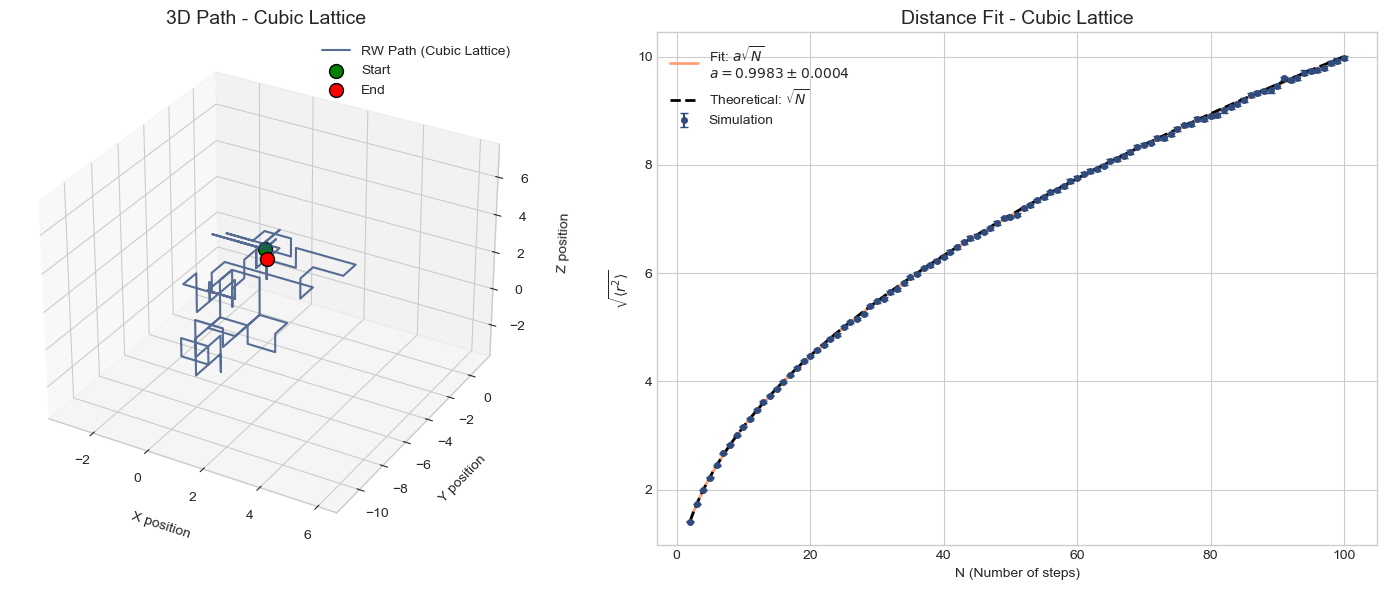

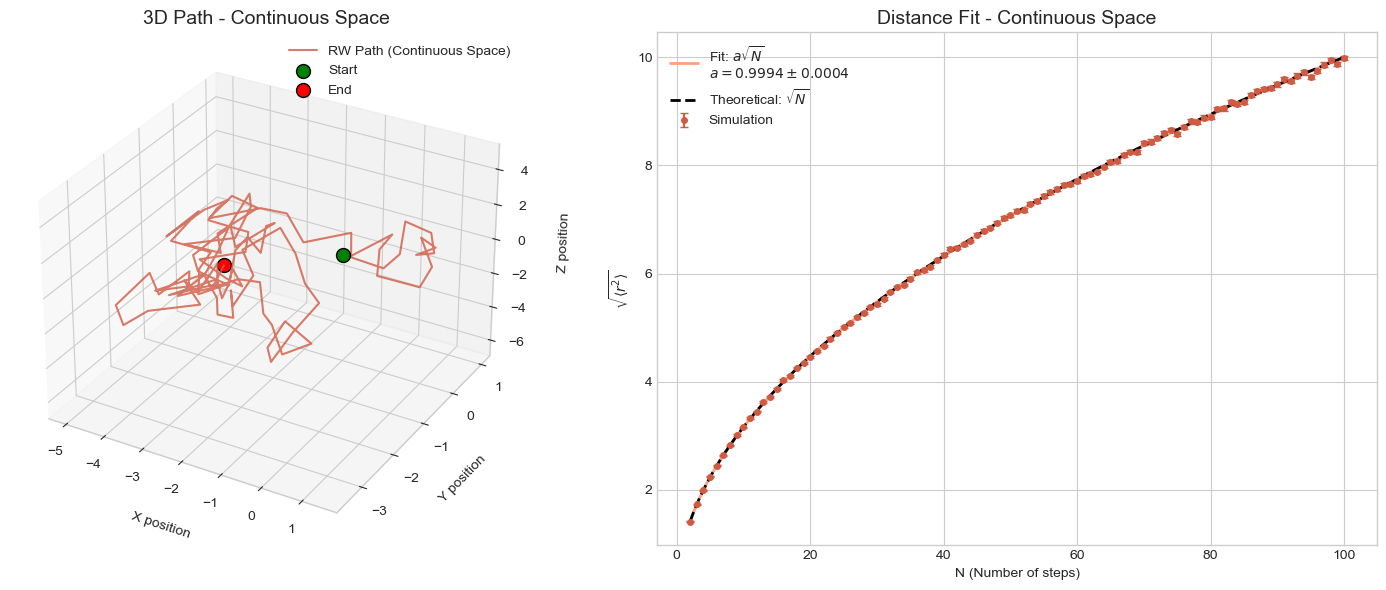

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Definizione del modello di fit comune
def model(x, a):
    return a * np.sqrt(x)

def plot_random_walk(path_file, data_file, title_suffix, path_color, sim_color, output_filename):
    """
    Funzione per generare la figura a due pannelli: 
    1. Percorso 3D del Random Walk
    2. Fit della distanza media in funzione di N con barre d'errore
    """
    # Impostazione stile
    plt.style.use('seaborn-v0_8-whitegrid')
    fig = plt.figure(figsize=(15, 6))

    # ==========================================
    # 1. Grafico 3D (Percorso)
    # ==========================================
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    x_rw, y_rw, z_rw = np.loadtxt(path_file, unpack=True)

    ax1.plot(x_rw, y_rw, z_rw, linestyle='-', marker='', color=path_color, alpha=0.8, linewidth=1.5, label=f'RW Path ({title_suffix})')
    ax1.scatter(x_rw[0], y_rw[0], z_rw[0], color='green', s=100, label='Start', zorder=5, edgecolors='black')
    ax1.scatter(x_rw[-1], y_rw[-1], z_rw[-1], color='red', s=100, label='End', zorder=5, edgecolors='black')

    ax1.set_xlabel('X position', labelpad=10)
    ax1.set_ylabel('Y position', labelpad=10)
    ax1.set_zlabel('Z position', labelpad=10)
    ax1.set_title(f'3D Path - {title_suffix}', fontsize=14)
    ax1.legend()

    # ==========================================
    # 2. Grafico del Fit (Distanza vs N)
    # ==========================================
    ax2 = fig.add_subplot(1, 2, 2)
    x, y, err = np.loadtxt(data_file, unpack=True)

    # Esecuzione del fit
    popt, pcov = curve_fit(model, x, y, sigma=err, absolute_sigma=True)
    a_fit, a_err = popt[0], np.sqrt(pcov[0, 0])

    x_fit = np.linspace(min(x), max(x), 300)
    ax2.errorbar(x, y, yerr=err, fmt='o', markersize=4, capsize=3, label='Simulation', color=sim_color)
    ax2.plot(x_fit, model(x_fit, a_fit), linewidth=2, color='#FFA07A' if sim_color != '#FFA07A' else '#2F4B7C', 
             label=fr'Fit: $a\sqrt{{N}}$' + '\n' + fr'$a={a_fit:.4f} \pm {a_err:.4f}$')
    ax2.plot(x_fit, np.sqrt(x_fit), linestyle='--', linewidth=2, color='black', label=r'Theoretical: $\sqrt{N}$')

    ax2.set_title(f'Distance Fit - {title_suffix}', fontsize=14)
    ax2.set_xlabel('N (Number of steps)')
    ax2.set_ylabel(r'$\sqrt{\langle r^2 \rangle}$')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(output_filename, dpi=300)
    plt.show()

# ==========================================
# Esecuzione per il Reticolo Cubico
# ==========================================
plot_random_walk(
    path_file="EX2.2/DATA/rwsteps.dat",
    data_file="EX2.2/DATA/ValuesRWCubic.dat",
    title_suffix="Cubic Lattice",
    path_color="#2F4B7C",
    sim_color="#2F4B7C",
    output_filename="IMAGES/RW_Cubic.png"
)

# ==========================================
# Esecuzione per lo Spazio Continuo
# ==========================================
plot_random_walk(
    path_file="EX2.2/DATA/rwstepscontinous.dat",
    data_file="EX2.2/DATA/ValuesRWContinuos.dat",
    title_suffix="Continuous Space",
    path_color="#D05B43",
    sim_color="#D05B43",
    output_filename="IMAGES/RW_Continuous.png"
)

Both plots $\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$ show a diffusive behaviour since both plots can be fitted with functions of type $\sqrt{N}$ which is exactly the result observed for the diffusive behaviour in a 1-dimensional case in the case of an initial distibution $p(x,0) = \delta(x)$.